In [25]:
# ===================================================================
# CELDA 1: INSTALACIÓN DE LIBRERÍAS
# ===================================================================
# NFStream es la librería clave para analizar los archivos .pcap
# El resto son para manipulación de datos, IA y gráficos.
# El -q es para que la salida de la instalación sea más limpia (quiet).
# ===================================================================
!pip install -q nfstream pandas numpy scikit-learn matplotlib seaborn


In [26]:
# ===================================================================
# CELDA 2: IMPORTACIÓN DE MÓDULOS
# ===================================================================
import os
import pandas as pd
import numpy as np
import re
from datetime import datetime
from nfstream import NFStreamer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
import warnings
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PATH_DRIVE = '/content/drive/MyDrive'
# Ignoramos advertencias para mantener la salida limpia
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")


Mounted at /content/drive
Librerías importadas correctamente.


In [27]:
# ===================================================================
# CELDA 3: FUNCIÓN INTELIGENTE DE DESFASE
# ===================================================================
def obtener_desfase_por_csv(archivo_sync, archivo_csv):
    """
    Calcula el desfase temporal entre el timestamp del juego y el timestamp UNIX
    buscando una marca de sincronización en un archivo de log.
    """
    print(f"   -> Buscando sincronización para {archivo_csv}...")
    
    # Extrae la fecha y hora del nombre del fichero de telemetría (ej: YYYYMMDD_HHMMSS)
    match_csv = re.search(r"(\d{8}_\d{6})", archivo_csv)
    if not match_csv:
        raise ValueError("El nombre del CSV no tiene el formato de fecha esperado (YYYYMMDD_HHMMSS).")
    fecha_csv = match_csv.group(1)
    
    with open(archivo_sync, 'r') as f:
        for linea in f: # Buscar linea por linea en el archivo de sincronización
            patron = r"\[([\d\.]+)\] ==== \[SYNC_TELEMETRIA\] Tiempo interno: ([\d\.]+) ===="
            match = re.search(patron, linea) # Extrae el tiempo UNIX y el tiempo del juego
            if match:
                tiempo_unix = float(match.group(1))
                tiempo_juego_sec = float(match.group(2))
                
                # Compara si la fecha y hora del log coincide con la del archivo CSV
                fecha_unix_str = datetime.fromtimestamp(tiempo_unix).strftime("%Y%m%d_%H%M%S")
                if fecha_unix_str == fecha_csv:
                    desfase = tiempo_unix - tiempo_juego_sec
                    print(f"      [OK] Sincronización encontrada. Desfase: {desfase:.3f} s")
                    return desfase
                    
    raise ValueError(f"No se encontró en '{archivo_sync}' la fecha correspondiente al CSV '{archivo_csv}'")


In [28]:
# ===================================================================
# CELDA 4: FUNCIÓN DE PREPROCESAMIENTO Y FUSIÓN
# ===================================================================
def preprocesar_y_fusionar(archivo_csv, pcap_local, pcap_amigo, desfase, id_host, id_amigo, tipo_red, es_ataque, fase, tipo_ataque):
    """
    Toma los datos de telemetría y red, los fusiona y enriquece para la IA.
    """
    # --- 1. PREPARAR TELEMETRÍA ---
    df_juego = pd.read_csv(archivo_csv)
    df_juego['timestamp_real'] = df_juego['timestamp'] + desfase
    df_juego = df_juego.sort_values('timestamp_real')
    print(f"   -> Telemetría leída: {len(df_juego)} filas.")

    jugadores_ids = df_juego['player_id'].unique()
    if id_host not in jugadores_ids or id_amigo not in jugadores_ids:
        print(f"      [AVISO] IDs configurados ({id_host}, {id_amigo}) no coinciden con los del CSV: {jugadores_ids}. Revisa si alguien no se conectó.")
    
    df_juego_host = df_juego[df_juego['player_id'] == id_host].copy()
    df_juego_amigo = df_juego[df_juego['player_id'] == id_amigo].copy()
    print(f"      - Datos Host (ID {id_host}): {len(df_juego_host)} filas.")
    print(f"      - Datos Amigo (ID {id_amigo}): {len(df_juego_amigo)} filas.")

    # --- Función interna para procesar PCAPs ---
    def procesar_pcap(pcap_path, tipo_conexion_str):
        print(f"   -> Procesando PCAP {tipo_conexion_str} ({pcap_path})...")
        try:
            streamer = NFStreamer(source=pcap_path, statistical_analysis=True, active_timeout=1)
            df_red = streamer.to_pandas()
            if df_red is None or df_red.empty:
                print(f"      [AVISO] El PCAP '{pcap_path}' está vacío o no contiene flujos. Se omitirá.")
                return pd.DataFrame()
            
            print(f"      - Flujos de red encontrados: {len(df_red)}.")
            df_red['tipo_conexion'] = tipo_conexion_str
            df_red['timestamp_sec'] = df_red['bidirectional_first_seen_ms'] / 1000.0
            return df_red.sort_values('timestamp_sec')
        except Exception as e:
            print(f"      [ERROR] No se pudo procesar '{pcap_path}'. Error: {e}. Se omitirá.")
            return pd.DataFrame()

    # --- 2. PROCESAR Y FUSIONAR HOST (Local) ---
    df_red_local = procesar_pcap(pcap_local, 'local')
    df_combinado_host = pd.DataFrame()
    if not df_red_local.empty and not df_juego_host.empty:
        df_combinado_host = pd.merge_asof(
            df_juego_host, df_red_local, left_on='timestamp_real', right_on='timestamp_sec', direction='nearest', tolerance=0.2
        )
        print(f"   -> Fusión Host: {len(df_combinado_host)} filas combinadas.")
    # --- 3. PROCESAR Y FUSIONAR AMIGO (Cliente) ---
    df_red_amigo = procesar_pcap(pcap_amigo, 'amigo')
    df_combinado_amigo = pd.DataFrame()
    if not df_red_amigo.empty and not df_juego_amigo.empty:
        df_combinado_amigo = pd.merge_asof(
            df_juego_amigo, df_red_amigo, left_on='timestamp_real', right_on='timestamp_sec', direction='backward', tolerance=0.2
        )#nearest daba problemas con el desfase, así que usamos backward para asegurar que tomamos el último paquete antes del evento de juego.
        print(f"   -> Fusión Amigo: {len(df_combinado_amigo)} filas combinadas.")
    else:
        # Si el PCAP del amigo falla, es un error crítico para el entrenamiento.
        raise RuntimeError(f"Fallo crítico: no se pudieron obtener datos de red para el amigo en la sesión {archivo_csv}.")

    # --- 4. JUNTAR MUNDOS ---
    df_combinado = pd.concat([df_combinado_host, df_combinado_amigo], ignore_index=True)
    df_combinado = df_combinado.ffill().fillna(0)
    
    # --- 5. INGENIERÍA DE CARACTERÍSTICAS ---
    df_combinado['delta_yaw'] = df_combinado.groupby('player_id')['yaw'].diff().abs().fillna(0)
    df_combinado['delta_pitch'] = df_combinado.groupby('player_id')['pitch'].diff().abs().fillna(0)
    df_combinado['ratio_velocidad_bytes'] = df_combinado['velocity'] / (df_combinado['bidirectional_bytes'] + 1)
    df_combinado.replace([np.inf, -np.inf], 0, inplace=True)

    # --- 6. ETIQUETADO METODOLÓGICO ---
    df_combinado['tipo_red'] = tipo_red
    df_combinado['fase'] = fase
    df_combinado['tipo_ataque'] = tipo_ataque if es_ataque else 'ninguno'
    
    # Por defecto, asumimos que toda la partida es limpia (1)
    df_combinado['etiqueta_real'] = 1 

    # Si es una sesión de ataque, leemos tu archivo de registro físico
    if es_ataque:
        # Pon aquí la ruta absoluta a tu archivo de trampas generado por Ubuntu
        ruta_registro = f"{PATH_DRIVE}/registro_trampas.txt" # <-- 
        
        if os.path.exists(ruta_registro):
            intervalos_ataque = []
            inicio_temporal = None
            
            # Extraemos todos los START/STOP
            with open(ruta_registro, "r") as f:
                for linea in f:
                    partes = linea.strip().split()
                    if len(partes) >= 2:
                        try:
                            tiempo_unix = float(partes[0])
                            accion = partes[1].upper()
                            if accion == "START":
                                inicio_temporal = tiempo_unix
                            elif accion == "STOP" and inicio_temporal is not None:
                                intervalos_ataque.append([inicio_temporal, tiempo_unix])
                                inicio_temporal = None
                        except ValueError:
                            continue
                            
            if intervalos_ataque:
                tiempo_min = df_combinado['timestamp_real'].min()
                tiempo_max = df_combinado['timestamp_real'].max()
                ataques_en_esta_partida = 0
                
                for intervalo in intervalos_ataque:
                    inicio, fin = intervalo[0], intervalo[1]
                    
                    # Verificamos si este ataque pertenece a esta partida
                    if inicio <= tiempo_max and fin >= tiempo_min:
                        
                        # --- MAGIA: AJUSTE DE COLA PARA UDP FLOOD ---
                        if tipo_ataque == 'udp_flood':
                            # Miramos hasta 10 segundos después del STOP oficial
                            mascara_cola = (df_combinado['timestamp_real'] > fin) & (df_combinado['timestamp_real'] <= fin + 10.0)
                            df_cola = df_combinado[mascara_cola]
                            
                            if not df_cola.empty:
                                # Calculamos los bytes por paquete de los flujos residuales
                                paquetes = df_cola['src2dst_packets'].replace(0, 1)
                                tamano_medio = df_cola['src2dst_bytes'] / paquetes
                                
                                # Si el tamaño medio se acerca a tus 1024 bytes (le damos un margen de >900 por cabeceras/ruido)
                                # O si hay un volumen absurdo de paquetes
                                condicion_residual = (tamano_medio > 900) | (df_cola['src2dst_packets'] > 500)
                                
                                if condicion_residual.any():
                                    nuevo_fin = df_cola[condicion_residual]['timestamp_real'].max()
                                    print(f"      - [AJUSTE UDP] Búfer residual detectado. STOP extendido de {fin:.2f} a {nuevo_fin:.2f} (+{nuevo_fin - fin:.2f}s)")
                                    fin = nuevo_fin # Actualizamos el fin para el etiquetado
                        # --------------------------------------------
                        
                        # Etiquetamos el bloque con -1
                        mascara = (df_combinado['timestamp_real'] >= inicio) & (df_combinado['timestamp_real'] <= fin)
                        df_combinado.loc[mascara, 'etiqueta_real'] = -1
                        ataques_en_esta_partida += 1
                        
                print(f"      - Se aplicaron {ataques_en_esta_partida} eventos de {tipo_ataque} a esta sesión.")
        else:
            print(f"   -> [AVISO] No se encontró el archivo maestro '{ruta_registro}'.")
            
    
    # --- 7. RECORTAR EL FINAL (TRIM) ---
    # Eliminamos los últimos 3 segundos de la partida para evitar 
    # los falsos positivos generados por el cierre de la conexión.
    tiempo_maximo = df_combinado['timestamp_real'].max()
    df_combinado = df_combinado[df_combinado['timestamp_real'] <= (tiempo_maximo - 5.0)]

    return df_combinado

In [29]:
# ===================================================================
# CELDA 5: APRENDIZAJE AISLADO Y PREDICCIÓN GLOBAL
# ===================================================================
def entrenar_isolation_forest(df_completo):
    """
    Entrena un modelo IsolationForest usando solo datos limpios y de la fase 'train',
    y luego lo usa para predecir anomalías en todo el dataset.
    """
    print("\n[AI] Preparando datos para el entrenamiento...")
    
    # Lista de características para el modelo. Centralizarla aquí facilita su gestión.
    features = [
        # --- 1. Física del Juego (Telemetría de QuakeC) ---
        'velocity', 'delta_yaw', 'delta_pitch', 'is_attacking',
        
        # --- 2. Volumen y Dirección de Red (NFStream) ---
        'src2dst_packets', 'dst2src_packets', 
        'src2dst_bytes', 'dst2src_bytes',
        'bidirectional_duration_ms',
        
        # --- 3. Tiempos y Latencia (Detección de Lag Switches) ---
        'bidirectional_mean_piat_ms', 
        'bidirectional_stddev_piat_ms',
        
        # --- 4. Comportamiento de Paquetes (Detección de Flood) ---
        'bidirectional_mean_ps',
        'bidirectional_stddev_ps',
        
        # --- 5. Variable Sintética (Ingeniería de Características) ---
        'ratio_velocidad_bytes'
    ]
    
    # APRENDIZAJE: Solo usa el cliente, sin ataques, y de la fase "train"
    df_para_aprender = df_completo[
        (df_completo['tipo_conexion'] == 'amigo') & 
        (df_completo['etiqueta_real'] == 1) & 
        (df_completo['fase'] == 'train')
    ].copy()
    
    if len(df_para_aprender) == 0:
        raise ValueError("No hay datos de la fase 'train' (limpios y del amigo) para enseñar a la IA.")
            
    X_aprender = df_para_aprender[features].copy()
    
    # Normalizar las características para que ninguna domine sobre las otras
    scaler = StandardScaler()
    X_aprender_scaled = scaler.fit_transform(X_aprender)
    
    print("[AI] Entrenando modelo Isolation Forest con la línea base (Juego Limpio)...")
    modelo = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
    modelo.fit(X_aprender_scaled)
    
    # PREDICCIÓN: Juzgamos a TODOS los jugadores y todas las fases
    print("[AI] Aplicando el modelo entrenado a todo el histórico de partidas...")
    
    # Aseguramos que el dataset completo tenga las mismas columnas que el de entrenamiento
    for f in features:
        if f not in df_completo.columns:
            df_completo[f] = 0
            
    X_total = scaler.transform(df_completo[features].copy())
    df_completo['prediccion_ia'] = modelo.predict(X_total)
    
    anomalias = len(df_completo[df_completo['prediccion_ia'] == -1])
    normales = len(df_completo[df_completo['prediccion_ia'] == 1])
    print(f"   [OK] Veredicto global: {normales} registros normales, {anomalias} anomalías marcadas.")
    
    return modelo, df_completo, features, scaler


In [30]:
# ===================================================================
# CELDA 6: EVALUACIÓN CIENTÍFICA (TEST SET)
# ===================================================================
def evaluar_rendimiento(df_evaluacion):
    """
    Mide qué tan bien lo hizo la IA sobre los datos que nunca ha visto durante el entrenamiento.
    """
    print("\n[EVALUACIÓN] Generando métricas sobre el conjunto de TEST ciego...")
    
    # Extraemos exclusivamente los datos de la fase "test" para evaluar
    df_test = df_evaluacion[df_evaluacion['fase'] == 'test'].copy()
    
    if len(df_test) == 0:
        print("   [AVISO] No configuraste ninguna partida con fase='test'. No se puede realizar la evaluación final.")
        return
    
    y_real = df_test['etiqueta_real']
    y_predicha = df_test['prediccion_ia']
    
    print("\n=== REPORTE DE CLASIFICACIÓN (EXAMEN FINAL) ===")
    etiquetas_presentes = np.unique(np.concatenate([y_real, y_predicha]))
    nombres = []
    if -1 in etiquetas_presentes: nombres.append('Ataque (-1)')
    if 1 in etiquetas_presentes: nombres.append('Normal (1)')
    
    print(classification_report(y_real, y_predicha, labels=etiquetas_presentes, target_names=nombres, zero_division=0))
    
    matriz = confusion_matrix(y_real, y_predicha, labels=[-1, 1])
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predice: Ataque', 'Predice: Normal'], 
                yticklabels=['Real: Ataque', 'Real: Normal'])
    plt.title('Matriz de Confusión: Rendimiento del Anti-Cheat en el Test Set')
    plt.ylabel('Verdad Absoluta (Lo que pasó)')
    plt.xlabel('Predicción de la IA (Lo que detectó)')
    plt.tight_layout()
    
    # Guardar y mostrar la gráfica
    plt.savefig('matriz_confusion_test.png')
    print("\n   [OK] Gráfica guardada como 'matriz_confusion_test.png'")
    plt.show()

    # --- EVALUACIÓN BASADA EN EVENTOS (EVENT-BASED RECALL) ---
    print("\n" + "="*45)
    print("   MÉTRICA AVANZADA: DETECCIÓN POR EVENTOS")
    print("="*45)

    df_test_eventos = df_test[df_test['tipo_conexion'] == 'amigo'].copy()
    
    # 1. Identificamos qué filas son realmente ataques
    es_ataque_real = df_test_eventos['etiqueta_real'] == -1

    # 2. Agrupamos los ataques consecutivos para contar cuántas veces pulsaste F9
    # Esto crea un ID único cada vez que el estado cambia (de normal a ataque o viceversa)
    id_eventos = (es_ataque_real != es_ataque_real.shift()).cumsum()

    # 3. Nos quedamos solo con los bloques que son ataques reales
    bloques_ataque = df_test_eventos[es_ataque_real].groupby(id_eventos)

    total_ataques_fisicos = len(bloques_ataque)
    ataques_cazados = 0

    # 4. Comprobamos si la IA detectó AL MENOS un milisegundo dentro de cada bloque
    for event_id, bloque_datos in bloques_ataque:
        # Asumimos que la columna de la predicción de tu modelo se llama 'prediccion_ia'
        # Cambia 'prediccion_ia' por el nombre real de tu columna si es distinto (ej. 'y_pred')
        if (bloque_datos['prediccion_ia'] == -1).any():
            ataques_cazados += 1

    # 5. Imprimimos el resultado final
    if total_ataques_fisicos > 0:
        tasa_exito = (ataques_cazados / total_ataques_fisicos) * 100
        print(f"Total de inyecciones de trampa (Pulsaciones F9): {total_ataques_fisicos}")
        print(f"Trampas detectadas por la IA (al menos 1 vez):  {ataques_cazados}")
        print(f"Tasa de Éxito Real del Anti-Cheat:              {tasa_exito:.2f}%")
    else:
        print("No se encontraron eventos de ataque en este dataset.")
    print("="*45 + "\n")
    # ===================================================================
    # GRÁFICO DE LÍNEA DE TIEMPO (VERSIÓN MEJORADA Y SEPARADA)
    # ===================================================================

    print("[VISUALIZACIÓN] Generando gráfico de línea de tiempo mejorado...")

    # 1. Extraemos los datos del Test Set (solo la perspectiva del servidor/amigo)
    df_plot = df_test[df_test['tipo_conexion'] == 'amigo'].copy()

    # Sacamos las columnas como matrices de 2 dimensiones (1 fila, N columnas)
    # Esto es necesario para que cada barra se dibuje de forma independiente
    real_data = df_plot['etiqueta_real'].values[np.newaxis, :]
    pred_data = df_plot['prediccion_ia'].values[np.newaxis, :]

    # 2. Configuramos los colores (-1 es Rojo/Ataque, 1 es Azul/Normal)
    cmap_personalizado = ListedColormap(['red', '#1f77b4'])

    # 3. Creamos una figura con 2 subgráficos (uno encima del otro) compartiendo el eje X
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)

    # --- BARRA SUPERIOR: Verdad Absoluta ---
    # interpolation='nearest' elimina el efecto "borroso" o derretido
    ax1.imshow(real_data, aspect='auto', cmap=cmap_personalizado, vmin=-1, vmax=1, interpolation='nearest')
    ax1.set_yticks([]) # Eliminamos los picos y números del eje Y
    ax1.set_ylabel('Verdad Absoluta\n(Lo que hiciste)', rotation=0, labelpad=70, va='center', fontweight='bold', fontsize=11)

    # --- BARRA INFERIOR: Predicción IA ---
    ax2.imshow(pred_data, aspect='auto', cmap=cmap_personalizado, vmin=-1, vmax=1, interpolation='nearest')
    ax2.set_yticks([]) # Eliminamos los picos y números del eje Y
    ax2.set_ylabel('Predicción IA\n(Lo que detectó)', rotation=0, labelpad=70, va='center', fontweight='bold', fontsize=11)

    # 4. Ajustes estéticos finales
    ax2.set_xlabel('Evolución temporal (Filas del Test Set)', fontsize=11)
    fig.suptitle('Línea de Tiempo: Inyecciones de Lag Switch vs Detección de la IA', fontsize=14, fontweight='bold', y=1.05)

    # 5. Leyenda general
    leyenda = [Patch(color='#1f77b4', label='Tráfico Normal (Limpio)'), 
            Patch(color='red', label='Anomalía / Ataque (Trampa)')]
    fig.legend(handles=leyenda, loc='upper right', bbox_to_anchor=(0.95, 1.05))

    # Espacio en blanco entre las dos barras para que respiren
    plt.subplots_adjust(hspace=0.4) 

    # Guardamos la imagen final
    plt.savefig('timeline_ataques_real_separado.png', dpi=300, bbox_inches='tight')
    print("   [OK] Imagen guardada en tu entorno como 'timeline_ataques_real_separado.png'")

    plt.show()

In [31]:
# ===================================================================
# CELDA 7: CONFIGURACIÓN DEL EXPERIMENTO
# ===================================================================

# Ruta al archivo que sincroniza los tiempos.
ARCHIVO_SYNC_GLOBAL = f"{PATH_DRIVE}/sincronizacion_tiempos.txt"

# SESIONES DE JUEGO
# - fase='train': Datos limpios para que la IA aprenda qué es "normal".
# - fase='test': Datos con ataques para examinar a la IA.
# ===================================================================
sesiones_a_procesar = [
    # --- FASE DE ENTRENAMIENTO (Debe ser limpia para construir la normalidad) ---
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_215841.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"   
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_220345.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"  
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_220826.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"  
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_221150.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"   
    },
     
        # --- FASE DE TEST
    {
        "csv": f"{PATH_DRIVE}/Partidas12072026LagSwitch/dataset_telemetria_20260712_175633.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas12072026LagSwitch/trafico1_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas12072026LagSwitch/trafico1_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": True,
        "tipo_ataque": "LagSwitch",
        "fase": "test"  
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas27072026Flood/dataset_telemetria_20260727_164251.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas27072026Flood/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas27072026Flood/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": True,
        "tipo_ataque": "Flood",
        "fase": "test"   
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_221530.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "test"   
    }
]



====== PROCESANDO SESIÓN 1/7: /content/drive/MyDrive/Partidas02072026Bueno/dataset_telemetria_20260702_215841.csv ======
   -> Buscando sincronización para /content/drive/MyDrive/Partidas02072026Bueno/dataset_telemetria_20260702_215841.csv...
      [OK] Sincronización encontrada. Desfase: 1783029518.522 s
   -> Telemetría leída: 33249 filas.
      - Datos Host (ID 10): 15919 filas.
      - Datos Amigo (ID 9): 17330 filas.
   -> Procesando PCAP local (/content/drive/MyDrive/Partidas02072026Bueno/trafico_local.pcap)...
      - Flujos de red encontrados: 1194.
   -> Fusión Host: 15919 filas combinadas.
   -> Procesando PCAP amigo (/content/drive/MyDrive/Partidas02072026Bueno/trafico_amigo.pcap)...
      - Flujos de red encontrados: 1178.
   -> Fusión Amigo: 17330 filas combinadas.

====== PROCESANDO SESIÓN 2/7: /content/drive/MyDrive/Partidas02072026Bueno/dataset_telemetria_20260702_220345.csv ======
   -> Buscando sincronización para /content/drive/MyDrive/Partidas02072026Bueno/dataset_

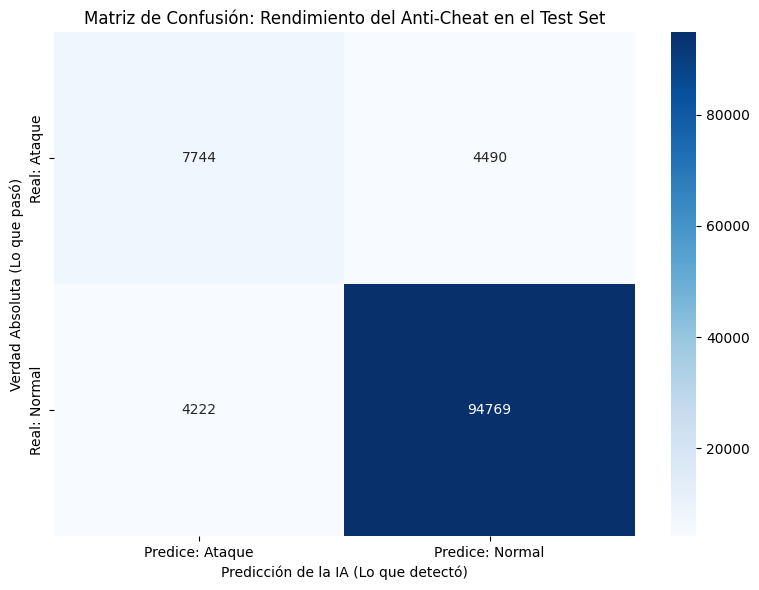


   MÉTRICA AVANZADA: DETECCIÓN POR EVENTOS
Total de inyecciones de trampa (Pulsaciones F9): 17
Trampas detectadas por la IA (al menos 1 vez):  16
Tasa de Éxito Real del Anti-Cheat:              94.12%

[VISUALIZACIÓN] Generando gráfico de línea de tiempo mejorado...
   [OK] Imagen guardada en tu entorno como 'timeline_ataques_real_separado.png'


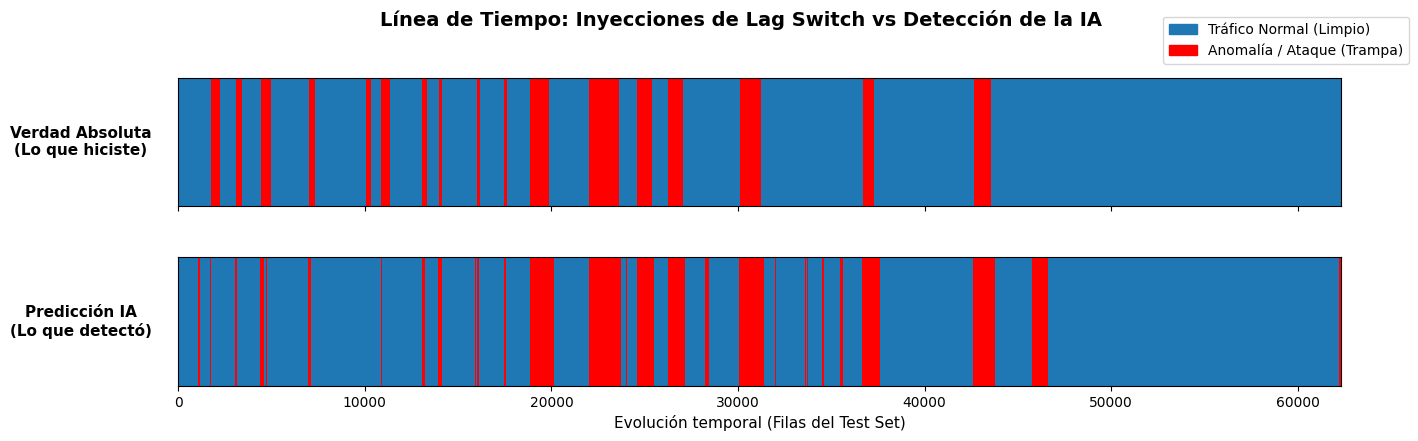



✅ ¡PROCESO FINALIZADO CON ÉXITO!


In [32]:
# ===================================================================
# CELDA 8: EJECUCIÓN DEL PROCESO COMPLETO
# ===================================================================
lista_datasets = []
all_files_exist = True

# Verificación inicial de archivos
if not os.path.exists(ARCHIVO_SYNC_GLOBAL):
    print(f"[ERROR CRÍTICO] No se encuentra el archivo de tiempos '{ARCHIVO_SYNC_GLOBAL}'. Súbelo a Colab.")
    all_files_exist = False
else:
    for sesion in sesiones_a_procesar:
        for key in ["csv", "pcap_local", "pcap_amigo"]:
            if not os.path.exists(sesion[key]):
                print(f"[ERROR] Falta el archivo '{sesion[key]}' para la sesión. Súbelo a Colab.")
                all_files_exist = False

# Solo si todos los archivos existen, procedemos.
if all_files_exist:
    try:
        # 1. Procesamiento masivo
        for i, sesion in enumerate(sesiones_a_procesar, 1):
            print(f"\n====== PROCESANDO SESIÓN {i}/{len(sesiones_a_procesar)}: {sesion['csv']} ======")
            desfase = obtener_desfase_por_csv(ARCHIVO_SYNC_GLOBAL, sesion['csv'])
            
            df_sesion = preprocesar_y_fusionar(
                sesion['csv'], sesion['pcap_local'], sesion['pcap_amigo'], 
                desfase, sesion['id_host'], sesion['id_amigo'],
                sesion['tipo_red'], sesion['es_ataque'], sesion['fase'],
                sesion.get('tipo_ataque', 'ninguno')
            )
            lista_datasets.append(df_sesion)
            
        if not lista_datasets:
            raise ValueError("Ninguna sesión pudo ser procesada. Revisa los nombres de tus archivos y los IDs de jugador.")

        print("\n=> Uniendo todas las sesiones en un Dataset Maestro...")
        dataset_maestro = pd.concat(lista_datasets, ignore_index=True)
        
        # 2. Entrenamiento y Predicción
        print(dataset_maestro)
        modelo_entrenado, dataset_final, features, scaler = entrenar_isolation_forest(dataset_maestro)
        
        # 3. Volcado de datos para análisis posterior
        nombre_salida = "dataset_global_evaluado.csv"
        dataset_final.to_csv(nombre_salida, index=False)
        print(f"\n=> [OK] Dataset final con predicciones exportado a '{nombre_salida}'")
        
        # 4. Evaluación Científica
        evaluar_rendimiento(dataset_final)
        
        print("\n\n¡PROCESO FINALIZADO CON ÉXITO!")
        
    except Exception as e:
        print(f"\n[ERROR FATAL] La ejecución se detuvo: {e}")

